In [8]:
!pip install -q tensorflow scikit-learn nltk

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    LSTM,
    GRU,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# ==========================================================
# Cell 3 — Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os

print(os.listdir('/content/drive/MyDrive'))

['software_data', 'Colab Notebooks', 'archive']


In [12]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/drive/MyDrive/software_data/dataset/pigmentation/_classes.csv
/content/drive/MyDrive/archive/WELFake_Dataset.csv


In [13]:
# ==========================================================
# Cell 4 — Load WELFake Dataset
# ==========================================================

import pandas as pd

dataset_path = "/content/drive/MyDrive/archive/WELFake_Dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [14]:
# ==========================================================
# Cell 5 — Display Dataset
# ==========================================================

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [15]:
# ==========================================================
# Cell 6 — Dataset Information
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)
print(df.columns.tolist())

print("\n")

print("=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

Dataset Shape
(72134, 4)


Column Names
['Unnamed: 0', 'title', 'text', 'label']


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [16]:
# ==========================================================
# Check Total Values in Each Column
# ==========================================================

summary = pd.DataFrame({
    "Total Values": len(df),
    "Non-Missing Values": df.count(),
    "Missing Values": df.isnull().sum()
})

print(summary)

            Total Values  Non-Missing Values  Missing Values
Unnamed: 0         72134               72134               0
title              72134               71576             558
text               72134               72095              39
label              72134               72134               0


In [17]:
# ==========================================================
# Cell 7 — Missing Values
# ==========================================================

missing_values = df.isnull().sum()

print(missing_values)

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [18]:
# ==========================================================
# Dataset Summary
# ==========================================================

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Total Values": len(df),
    "Non-Missing Values": df.count(),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": round(df.isnull().mean() * 100, 2)
})

summary

,Data Type,Total Values,Non-Missing Values,Missing Values,Missing (%)
Unnamed: 0,int64,72134,72134,0,0.00
title,object,72134,71576,558,0.77
text,object,72134,72095,39,0.05
label,int64,72134,72134,0,0.00


In [19]:
# ==========================================================
# Cell 9 — Check Duplicate Rows
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [20]:
# ==========================================================
# Cell 10 — Class Distribution(CHECKING THE BALANCING OF DATASET)
# ==========================================================

print(df["label"].value_counts())

label
1    37106
0    35028
Name: count, dtype: int64


In [21]:
# ==========================================================
# Cell 13 — Remove Unnecessary Column
# ==========================================================

df.drop(columns=["Unnamed: 0"], inplace=True)

print("Current Columns:")
print(df.columns.tolist())

Current Columns:
['title', 'text', 'label']


In [22]:
# ==========================================================
# Cell 14 — Remove Missing Values
# ==========================================================

print("Shape Before Removing Missing Values:", df.shape)

# Remove rows where title or text is missing
df.dropna(subset=["title", "text"], inplace=True)

print("Shape After Removing Missing Values:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

Shape Before Removing Missing Values: (72134, 3)
Shape After Removing Missing Values: (71537, 3)

Remaining Missing Values:
title    0
text     0
label    0
dtype: int64


In [23]:
# ==========================================================
# Cell 15 — Rows Removed
# ==========================================================

rows_removed = 72134 - len(df)

print("Rows Removed:", rows_removed)
print("Remaining Rows:", len(df))

Rows Removed: 597
Remaining Rows: 71537


In [24]:
# ==========================================================
# Cell 16 — Verify Dataset
# ==========================================================

print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 71537 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71537 non-null  object
 1   text    71537 non-null  object
 2   label   71537 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB
None


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


In [25]:
# ==========================================================
# Cell 16 — Create Content Column
# ==========================================================

# Combine the title and text into a single feature
df["content"] = df["title"] + " " + df["text"]

# Display the first few rows
df[["content", "label"]].head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [26]:
# ==========================================================
# Cell 17 — Keep Only Required Columns
# ==========================================================

# Keep only the input text and target label
df = df[["content", "label"]]

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (71537, 2)


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [27]:
# ==========================================================
# Cell 18 — Verify Final Dataset
# ==========================================================

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 71537 entries, 0 to 72133
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  71537 non-null  object
 1   label    71537 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ MB
None

Missing Values:
content    0
label      0
dtype: int64

Class Distribution:
label
1    36509
0    35028
Name: count, dtype: int64


In [28]:
# Save cleaned dataset as CSV
df.to_csv("WELFake_Cleaned.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [29]:
from google.colab import files

files.download("WELFake_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# ==========================================================
# Cell 19 — Install NLTK
# ==========================================================

!pip install nltk -q

In [31]:
# ==========================================================
# Cell 20 — Import Libraries
# ==========================================================

import re
import string
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
# ==========================================================
# Cell 21 — Text Cleaning Function
# ==========================================================

stop_words = set(stopwords.words("english"))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [33]:
# ==========================================================
# Cell 22 — Apply Text Cleaning
# ==========================================================

df["content"] = df["content"].apply(clean_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


In [34]:
# ==========================================================
# Cell 23 — Compare Original vs Cleaned Text
# ==========================================================

sample_text = df["content"].iloc[0]

print(sample_text[:1000])

law enforcement high alert following threats cops whites blacklivesmatter fyf terrorists video comment expected barack obama members fyf fukyoflag blacklivesmatter movements called lynching hanging white people cops encouraged others radio show tuesday night turn tide kill white people cops send message killing black people americaone fyoflag organizers called sunshine radio blog show hosted texas called sunshine fing opinion radio show snapshot fyf lolatwhitefear twitter page pm shows urging supporters call fyf tonight continue dismantle illusion white snapshot twitter radio call invite fyfthe radio show aired pm eastern standard timeduring show callers clearly call lynching killing white peoplea minute clip radio show heard provided breitbart texas someone would like referred hannibal already received death threats result interrupting fyf conference callsan unidentified black man said mother fkers start fing like us bunch niers takin one us roll said cause already roll gangs anyway s

In [35]:
# ==========================================================
# Cell 24 — Split Dataset (70% Train, 20% Test, 10% Validation)
# ==========================================================

from sklearn.model_selection import train_test_split

# Features and target
X = df["content"]
y = df["label"]

# Step 1: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split the remaining 30% into
# 20% Test and 10% Validation
# (20/30 = 0.6667 for test, 10/30 = 0.3333 for validation)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print("Validation Set:", X_val.shape)

Training Set : (50075,)
Testing Set  : (14308,)
Validation Set: (7154,)


In [36]:
# ==========================================================
# Cell 25 — Check Class Distribution
# ==========================================================

print("Training Set")
print(y_train.value_counts(normalize=True))

print("\nTesting Set")
print(y_test.value_counts(normalize=True))

print("\nValidation Set")
print(y_val.value_counts(normalize=True))

Training Set
label
1    0.510354
0    0.489646
Name: proportion, dtype: float64

Testing Set
label
1    0.510344
0    0.489656
Name: proportion, dtype: float64

Validation Set
label
1    0.510344
0    0.489656
Name: proportion, dtype: float64


In [37]:
# ==========================================================
# Cell 26 — Import TF-IDF Vectorizer
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
# ==========================================================
# Cell 27 — Initialize TF-IDF Vectorizer
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

In [39]:
# ==========================================================
# Cell 28 — TF-IDF Feature Extraction
# ==========================================================

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

X_val_tfidf = tfidf.transform(X_val)

print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape  :", X_test_tfidf.shape)
print("Validation Shape:", X_val_tfidf.shape)

Training Shape : (50075, 5000)
Testing Shape  : (14308, 5000)
Validation Shape: (7154, 5000)


In [40]:
# ==========================================================
# Cell 29 — Display Sample TF-IDF Features
# ==========================================================

feature_names = tfidf.get_feature_names_out()

print("Number of Features:", len(feature_names))

print("\nFirst 20 Features:")
print(feature_names[:20])

Number of Features: 5000

First 20 Features:
['abandoned' 'abc' 'abc news' 'abe' 'abedin' 'ability' 'able' 'abortion'
 'abortions' 'abroad' 'absence' 'absolute' 'absolutely' 'abu' 'abuse'
 'abuses' 'academic' 'academy' 'accept' 'acceptable']


In [41]:
# ==========================================================
# Cell 30 — Import Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# ==========================================================
# Cell 31 — Train Logistic Regression
# ==========================================================

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [43]:
# ==========================================================
# Cell 32 — Predict on Test Set
# ==========================================================

y_pred = lr_model.predict(X_test_tfidf)

y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

In [44]:
# ==========================================================
# Cell 33 — Model Evaluation
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9493
Precision: 0.9444
Recall   : 0.9569
F1-Score : 0.9506
ROC-AUC  : 0.9888


In [45]:
# ==========================================================
# Cell 34 — Classification Report
# ==========================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7006
           1       0.94      0.96      0.95      7302

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



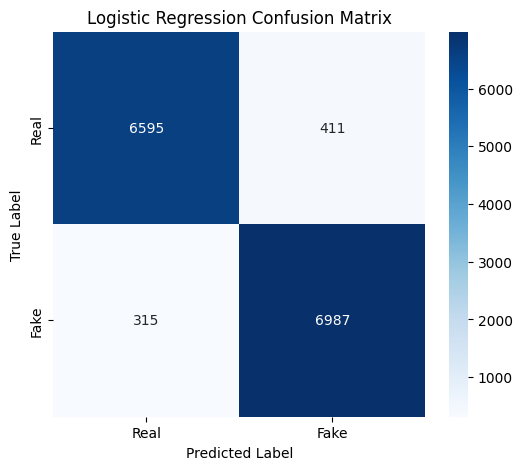

In [46]:
# ==========================================================
# Cell 35 — Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

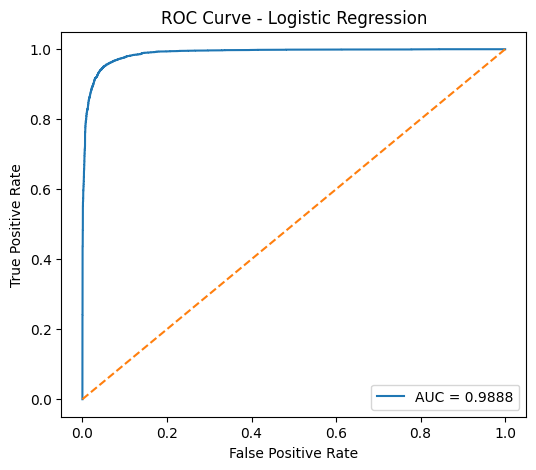

In [47]:
# ==========================================================
# Cell 36 — ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [48]:
# ==========================================================
# Cell 37 — Save Logistic Regression Results
# ==========================================================

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

print(lr_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.9492591557170813, 'Precision': 0.9444444444444444, 'Recall': 0.956861133935908, 'F1-Score': 0.9506122448979591, 'ROC-AUC': np.float64(0.9888226259559341)}


In [49]:
# ==========================================================
# Cell 38 — Import Naïve Bayes
# ==========================================================

from sklearn.naive_bayes import MultinomialNB

In [50]:
# ==========================================================
# Cell 39 — Train Naïve Bayes
# ==========================================================

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naïve Bayes Model Trained Successfully!")

Naïve Bayes Model Trained Successfully!


In [51]:
# ==========================================================
# Cell 40 — Predict on Test Set
# ==========================================================

y_pred_nb = nb_model.predict(X_test_tfidf)

y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

In [52]:
# ==========================================================
# Cell 41 — Model Evaluation
# ==========================================================

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_prob_nb)

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")
print(f"ROC-AUC  : {roc_auc_nb:.4f}")

Accuracy : 0.8565
Precision: 0.8460
Recall   : 0.8788
F1-Score : 0.8621
ROC-AUC  : 0.9295


In [53]:
# ==========================================================
# Cell 42 — Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7006
           1       0.85      0.88      0.86      7302

    accuracy                           0.86     14308
   macro avg       0.86      0.86      0.86     14308
weighted avg       0.86      0.86      0.86     14308



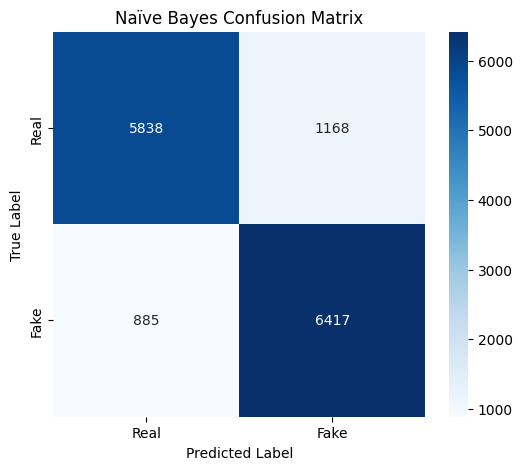

In [54]:
# ==========================================================
# Cell 43 — Confusion Matrix
# ==========================================================

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Naïve Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

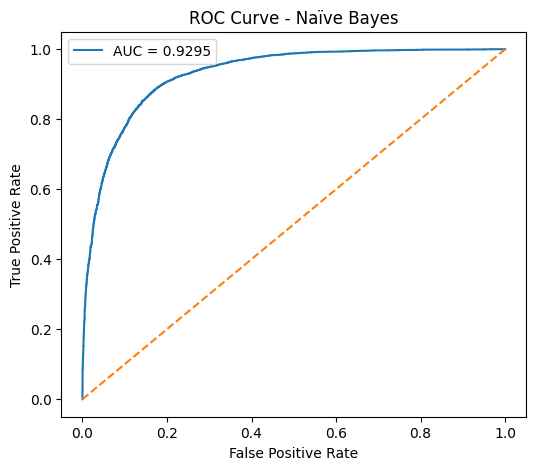

In [55]:
# ==========================================================
# Cell 44 — ROC Curve
# ==========================================================

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(6,5))

plt.plot(fpr_nb, tpr_nb, label=f"AUC = {roc_auc_nb:.4f}")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naïve Bayes")

plt.legend()

plt.show()

In [56]:
# ==========================================================
# Cell 45 — Save Naïve Bayes Results
# ==========================================================

nb_results = {
    "Model": "Naïve Bayes",
    "Accuracy": accuracy_nb,
    "Precision": precision_nb,
    "Recall": recall_nb,
    "F1-Score": f1_nb,
    "ROC-AUC": roc_auc_nb
}

print(nb_results)

{'Model': 'Naïve Bayes', 'Accuracy': 0.8565138384120772, 'Precision': 0.8460118655240606, 'Recall': 0.8788003286770748, 'F1-Score': 0.8620944448176261, 'ROC-AUC': np.float64(0.9295028684964087)}


In [57]:
# ==========================================================
# Cell 46 — Import Support Vector Machine
# ==========================================================

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

In [58]:
# ==========================================================
# Cell 47 — Train Support Vector Machine
# ==========================================================

svm_model = CalibratedClassifierCV(
    estimator=LinearSVC(random_state=42),
    cv=5
)

svm_model.fit(X_train_tfidf, y_train)

print("Support Vector Machine Model Trained Successfully!")

Support Vector Machine Model Trained Successfully!


In [59]:
# ==========================================================
# Cell 48 — Predict on Test Set
# ==========================================================

y_pred_svm = svm_model.predict(X_test_tfidf)

y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

In [60]:
# ==========================================================
# Cell 49 — Model Evaluation
# ==========================================================

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

Accuracy : 0.9580
Precision: 0.9562
Recall   : 0.9618
F1-Score : 0.9590
ROC-AUC  : 0.9918


In [61]:
# ==========================================================
# Cell 50 — Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7006
           1       0.96      0.96      0.96      7302

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



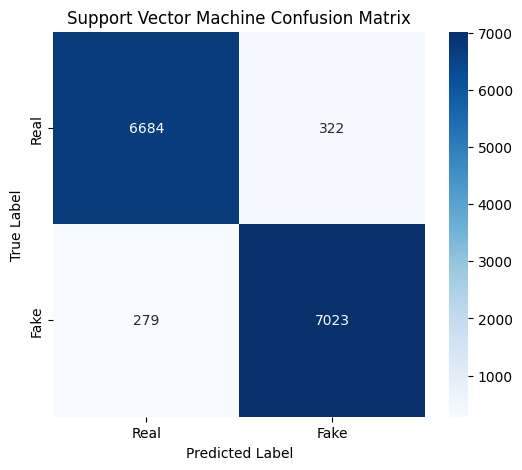

In [62]:
# ==========================================================
# Cell 51 — Confusion Matrix
# ==========================================================

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

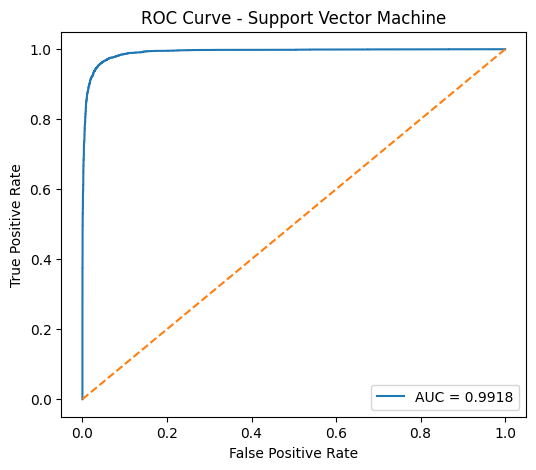

In [63]:
# ==========================================================
# Cell 52 — ROC Curve
# ==========================================================

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))

plt.plot(fpr_svm, tpr_svm, label=f"AUC = {roc_auc_svm:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Support Vector Machine")

plt.legend()

plt.show()

In [64]:
# ==========================================================
# Cell 53 — Save SVM Results
# ==========================================================

svm_results = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1-Score": f1_svm,
    "ROC-AUC": roc_auc_svm
}

print(svm_results)

{'Model': 'Support Vector Machine', 'Accuracy': 0.9579955269779145, 'Precision': 0.9561606535057863, 'Recall': 0.9617912900575185, 'F1-Score': 0.9589677066976172, 'ROC-AUC': np.float64(0.9917573879039235)}


In [65]:
# ==========================================================
# Cell 54 — Import Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

In [66]:
# ==========================================================
# Cell 55 — Train Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [67]:
# ==========================================================
# Cell 56 — Predict on Test Set
# ==========================================================

y_pred_rf = rf_model.predict(X_test_tfidf)

y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:,1]

In [68]:
# ==========================================================
# Cell 57 — Model Evaluation
# ==========================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.9588
Precision: 0.9478
Recall   : 0.9727
F1-Score : 0.9601
ROC-AUC  : 0.9934


In [69]:
# ==========================================================
# Cell 58 — Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      7006
           1       0.95      0.97      0.96      7302

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



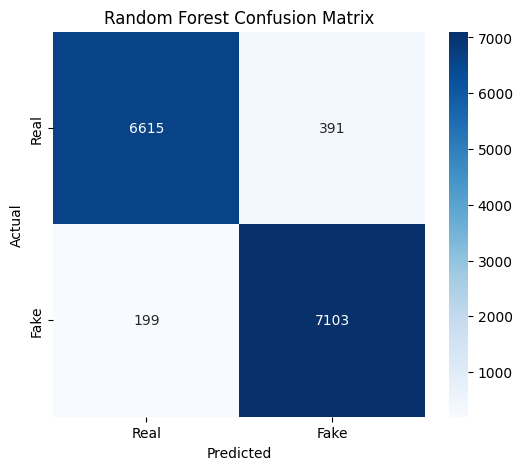

In [70]:
# ==========================================================
# Cell 59 — Confusion Matrix
# ==========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

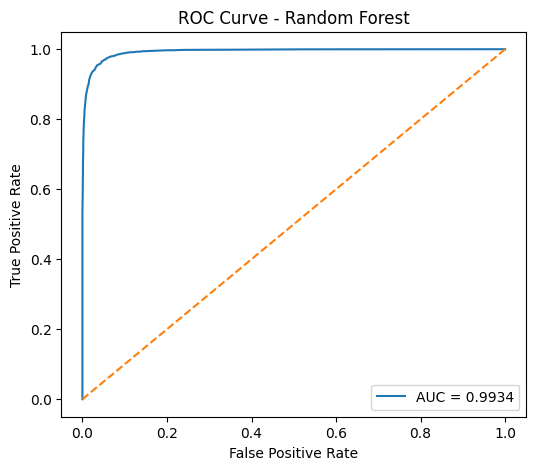

In [71]:
# ==========================================================
# Cell 60 — ROC Curve
# ==========================================================

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [72]:
# ==========================================================
# Cell 61 — Save Random Forest Results
# ==========================================================

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-Score": f1_rf,
    "ROC-AUC": roc_auc_rf
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.9587643276488678, 'Precision': 0.947824926607953, 'Recall': 0.9727471925499863, 'F1-Score': 0.960124357934577, 'ROC-AUC': np.float64(0.9934199296873759)}


In [73]:
# ==========================================================
# Cell 62 — Machine Learning Models Comparison
# ==========================================================

import pandas as pd

comparison = pd.DataFrame([
    lr_results,
    svm_results,
    rf_results
])

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.958764,0.947825,0.972747,0.960124,0.993420
1,Support Vector Machine,0.957996,0.956161,0.961791,0.958968,0.991757
2,Logistic Regression,0.949259,0.944444,0.956861,0.950612,0.988823


In [74]:
# ==========================================================
# Cell 62 — Compare All Machine Learning Models
# ==========================================================

import pandas as pd

comparison = pd.DataFrame([
    lr_results,
    nb_results,
    svm_results,
    rf_results
])

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.958764,0.947825,0.972747,0.960124,0.993420
1,Support Vector Machine,0.957996,0.956161,0.961791,0.958968,0.991757
2,Logistic Regression,0.949259,0.944444,0.956861,0.950612,0.988823
3,Naïve Bayes,0.856514,0.846012,0.878800,0.862094,0.929503


In [75]:
# ==========================================================
# Cell 63 — Save Machine Learning Comparison
# ==========================================================

comparison.to_csv(
    "Machine_Learning_Models_Comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


In [76]:
# ==========================================================
# Cell 64 — Install Required Libraries
# ==========================================================

!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [77]:
# ==========================================================
# Cell 65 — Import Libraries
# ==========================================================

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("Libraries Imported Successfully!")

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries Imported Successfully!
PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU: Tesla T4


In [78]:
# ==========================================================
# Cell 66 — Check Device
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [79]:
# ==========================================================
# Cell 67 — Prepare Data for BERT
# ==========================================================

# Features and labels
X = df["content"]
y = df["label"]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 20% test, 10% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

print("Training:", len(X_train))
print("Testing :", len(X_test))
print("Validation:", len(X_val))

Training: 50075
Testing : 14308
Validation: 7154


In [80]:
# ==========================================================
# Cell 68 — Load BERT Tokenizer
# ==========================================================

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("BERT Tokenizer Loaded Successfully!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT Tokenizer Loaded Successfully!


In [81]:
# ==========================================================
# Cell 69 — Tokenize the Dataset
# ==========================================================

MAX_LENGTH = 256

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

print("Tokenization Completed!")

Tokenization Completed!


In [82]:
# ==========================================================
# Cell 70 — Create PyTorch Dataset
# ==========================================================

from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = FakeNewsDataset(train_encodings, y_train)
val_dataset = FakeNewsDataset(val_encodings, y_val)
test_dataset = FakeNewsDataset(test_encodings, y_test)

print("Datasets Created Successfully!")
print("Training Samples :", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Testing Samples  :", len(test_dataset))

Datasets Created Successfully!
Training Samples : 50075
Validation Samples: 7154
Testing Samples  : 14308


In [83]:
# ==========================================================
# Cell 71 — Load BERT Model
# ==========================================================

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

print("BERT Model Loaded Successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Model Loaded Successfully!


In [84]:
# ==========================================================
# Cell 72 — Training Arguments
# ==========================================================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training Arguments Ready!")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Arguments Ready!


In [85]:
# ==========================================================
# Cell 73 — Evaluation Metrics
# ==========================================================

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1.compute(predictions=predictions, references=labels)["f1"],
    }

In [86]:
# ==========================================================
# Cell 74 — Create Trainer
# ==========================================================

from transformers import Trainer


trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)


print("BERT Trainer Created Successfully!")

BERT Trainer Created Successfully!


In [87]:
# ==========================================================
# Cell 75 — Train BERT Model
# ==========================================================

trainer.train()

print("BERT Training Completed Successfully!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.066804,0.045653,0.987839,0.994725,0.981375,0.988005
2,0.008065,0.044223,0.990774,0.990424,0.991509,0.990966


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT Training Completed Successfully!


In [88]:
# ==========================================================
# Cell 76 — Evaluate BERT on Test Dataset
# ==========================================================

test_results = trainer.evaluate(test_dataset)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.008065,0.047408,2,0.990425,0.988678,0.992605,0.990638


{'eval_loss': 0.04740798845887184, 'eval_accuracy': 0.990424937098127, 'eval_precision': 0.9886782157959351, 'eval_recall': 0.9926047658175843, 'eval_f1': 0.9906375999453291}


In [89]:
# ==========================================================
# Cell 77 — BERT Test Predictions
# ==========================================================

predictions = trainer.predict(test_dataset)

y_pred_bert = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_bert = predictions.label_ids

print("BERT Predictions Generated Successfully!")

BERT Predictions Generated Successfully!


In [90]:
# ==========================================================
# Cell 78 — BERT Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=["Real News", "Fake News"]
))

              precision    recall  f1-score   support

   Real News       0.99      0.99      0.99      7006
   Fake News       0.99      0.99      0.99      7302

    accuracy                           0.99     14308
   macro avg       0.99      0.99      0.99     14308
weighted avg       0.99      0.99      0.99     14308



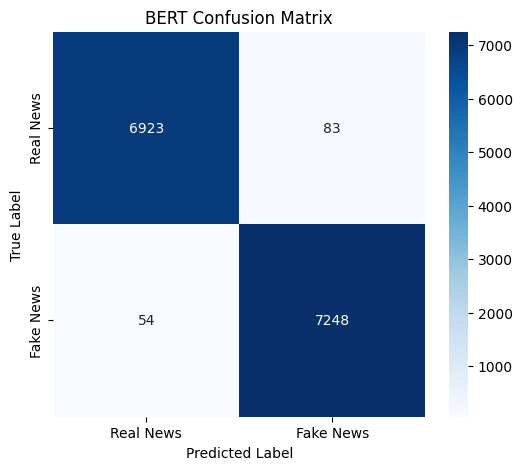

In [91]:
# ==========================================================
# Cell 79 — BERT Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_bert = confusion_matrix(
    y_true_bert,
    y_pred_bert
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real News", "Fake News"],
    yticklabels=["Real News", "Fake News"]
)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [92]:
# ==========================================================
# Cell 80 — BERT ROC-AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores for Fake News class
y_prob_bert = predictions.predictions[:, 1]

roc_auc_bert = roc_auc_score(
    y_true_bert,
    y_prob_bert
)

print(f"BERT ROC-AUC: {roc_auc_bert:.4f}")

BERT ROC-AUC: 0.9994


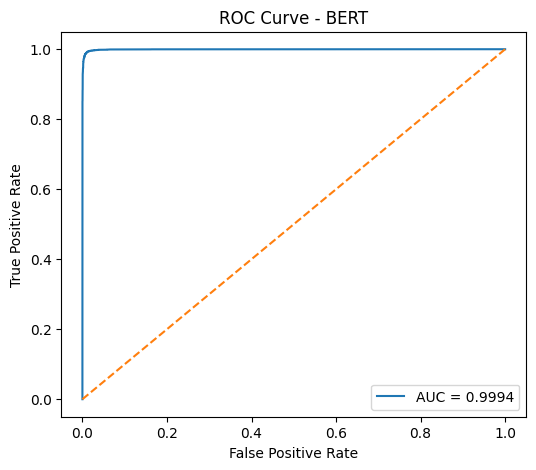

In [93]:
# ==========================================================
# Cell 81 — BERT ROC Curve
# ==========================================================

fpr_bert, tpr_bert, _ = roc_curve(
    y_true_bert,
    y_prob_bert
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_bert,
    tpr_bert,
    label=f"AUC = {roc_auc_bert:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - BERT")

plt.legend()

plt.show()

In [95]:
import pandas as pd

# BERT results
bert_results = {
    "Model": "BERT",
    "Accuracy": accuracy_score(y_true_bert, y_pred_bert),
    "Precision": precision_score(y_true_bert, y_pred_bert),
    "Recall": recall_score(y_true_bert, y_pred_bert),
    "F1-Score": f1_score(y_true_bert, y_pred_bert),
    "ROC-AUC": roc_auc_bert
}

# Combine all models
final_comparison = pd.DataFrame([
    lr_results,
    nb_results,
    svm_results,
    rf_results,
    bert_results
])

# Sort by accuracy
final_comparison = final_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(final_comparison)

# Save to CSV
final_comparison.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

print("\n✅ Final comparison saved as 'Final_Model_Comparison.csv'")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,BERT,0.990425,0.988678,0.992605,0.990638,0.999389
1,Random Forest,0.958764,0.947825,0.972747,0.960124,0.993420
2,Support Vector Machine,0.957996,0.956161,0.961791,0.958968,0.991757
3,Logistic Regression,0.949259,0.944444,0.956861,0.950612,0.988823
4,Naïve Bayes,0.856514,0.846012,0.878800,0.862094,0.929503



✅ Final comparison saved as 'Final_Model_Comparison.csv'


In [96]:
import joblib

# Save trained machine learning models
joblib.dump(lr_model, "logistic.pkl")
joblib.dump(nb_model, "naive.pkl")
joblib.dump(svm_model, "svm.pkl")
joblib.dump(rf_model, "random_forest.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf.pkl")

print("All models and the TF-IDF vectorizer have been saved successfully.")

All models and the TF-IDF vectorizer have been saved successfully.


In [97]:
import os

print(os.listdir())

['.config', 'random_forest.pkl', 'tfidf.pkl', 'Machine_Learning_Models_Comparison.csv', 'Final_Model_Comparison.csv', 'naive.pkl', 'WELFake_Cleaned.csv', 'bert_results', 'drive', 'svm.pkl', 'logistic.pkl', 'sample_data']


In [98]:
from google.colab import files

files.download("WELFake_Cleaned.csv")
files.download("Machine_Learning_Models_Comparison.csv")
files.download("tfidf.pkl")
files.download("logistic.pkl")
files.download("naive.pkl")
files.download("svm.pkl")
files.download("random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
df['label'].value_counts()

,count
label,
1,36509
0,35028
